## Day 6 — Task Sheet_NumPy Fundamentals 

 Part A — the 15 array puzzles

TASK 01__Puzzles 1–8: arrays, indexing, masking

In [ ]:
import numpy as np


# 1. Create numbers 1 to 20 and reverse them

numbers = np.arange(1, 21)
reversed_numbers = numbers[::-1]

print("1. Original:", numbers)
print("1. Reversed:", reversed_numbers)



# 2. Create 3x3 zeros and set middle element to 1

matrix = np.zeros((3, 3), dtype=int)
matrix[1, 1] = 1

print("\n2. Matrix:")
print(matrix)



# 3. Extract every third element

numbers = np.arange(20)
every_third = numbers[::3]

print("\n3. Original:", numbers)
print("3. Every third:", every_third)



# 4. Replace every odd number with -1

random_numbers = np.random.randint(1, 20, size=20)
random_numbers[random_numbers % 2 == 1] = -1

print("\n4. After replacing odd numbers:", random_numbers)



# 5. Find values greater than the array's mean


numbers = np.array([10, 20, 30, 40, 50])

mean_value = numbers.mean()
above_mean = numbers[numbers > mean_value]

print("\n5. Mean:", mean_value)
print("5. Values above mean:", above_mean)



# 6. Count values between 25 and 75 inclusive

numbers = np.array([10, 25, 30, 50, 75, 80, 90])

between_25_and_75 = (numbers >= 25) & (numbers <= 75)
count = between_25_and_75.sum()

print("\n6. Values:", numbers)
print("6. Count between 25 and 75:", count)



# 7. Find 5 largest values in descending order

numbers = np.array([45, 12, 89, 34, 67, 23, 91, 56, 78])

largest_five = np.sort(numbers)[-5:][::-1]

print("\n7. Original:", numbers)
print("7. 5 largest:", largest_five)


# 8. Swap first and last rows

matrix = np.array([
    [1, 2, 3],
    [4, 5, 6],
    [7, 8, 9]
])

matrix[[0, -1]] = matrix[[-1, 0]]

print("\n8. After swapping first and last rows:")
print(matrix)

Puzzle 7: What is the difference between np.sort and np.argsort? Which do you need?
Answer: np.sort() gives sorted values; np.argsort() gives the indices that would sort the array.

Puzzle 4: Can you assign into a boolean mask? Try arr[mask] = value.
Answer: Yes. It changes all elements where the mask is True.

Puzzle 6: Remember True == 1. What does .sum() on a mask give you?
Answer: It gives the number of True values in the mask.

## TASK 02__Puzzles 9–15: 2D, reshaping, aggregation

In [ ]:
import numpy as np

# 9. Create a 4×4 array containing numbers 1 to 16

grid = np.arange(1, 17).reshape(4, 4)
print(grid)



# 10. Extract the second column and last two rows

second_column = grid[:, 1]
last_two_rows = grid[-2:]

print(second_column)
print(last_two_rows)



# 11. Sum of each row and each column

row_sums = grid.sum(axis=1)       # axis=1 → rows
column_sums = grid.sum(axis=0)    # axis=0 → columns

print(row_sums)
print(column_sums)



# 12. Normalize each column

column_mean = grid.mean(axis=0)
column_std = grid.std(axis=0)

normalized_grid = (grid - column_mean) / column_std

print(normalized_grid)


# 13. Create a 5×5 array with 1s on border and 0s inside

border_array = np.zeros((5, 5), dtype=int)

border_array[0, :] = 1
border_array[-1, :] = 1
border_array[:, 0] = 1
border_array[:, -1] = 1

print(border_array)



# 14. Find the position of the largest element

largest_index = np.argmax(grid)

largest_position = np.unravel_index(
    largest_index,
    grid.shape
)

print(largest_position)



# 15. Stack two 1D arrays as rows and columns

first_array = np.array([1, 2, 3])
second_array = np.array([4, 5, 6])

as_rows = np.vstack(
    (first_array, second_array)
)

as_columns = np.column_stack(
    (first_array, second_array)
)

print(as_rows)
print(as_columns)

**Q13. Does `axis=0` collapse rows or columns?**
**Answer:** `axis=0` collapses **rows**.

**Q14. Why does `argmax()` return one number for a 2D array?**
**Answer:** It returns the index in the **flattened array**. Use `np.unravel_index()` for `(row, col)`.

**Q15. Difference between `vstack`, `hstack`, and `column_stack`?**
**Answer:** `vstack` = vertical, `hstack` = horizontal, `column_stack` = 1D arrays as columns.


## Part B — the curriculum tasks

## TASK 03__Convert loops to NumPy and measure the speedup

Operation              Size     Python (s)      NumPy (s)     Speedup
---------------------------------------------------------------------
Sum                   1,000       0.000005       0.000006       0.91x
Sum                  10,000       0.000043       0.000004      11.23x
Sum                 100,000       0.000622       0.000033      18.74x
Sum               1,000,000       0.006673       0.000389      17.17x
Dot Product           1,000       0.000057       0.000062       0.92x
Dot Product          10,000       0.000926       0.000007     128.54x
Dot Product         100,000       0.010536       0.000054     193.99x
Dot Product       1,000,000       0.126070       0.000911     138.44x


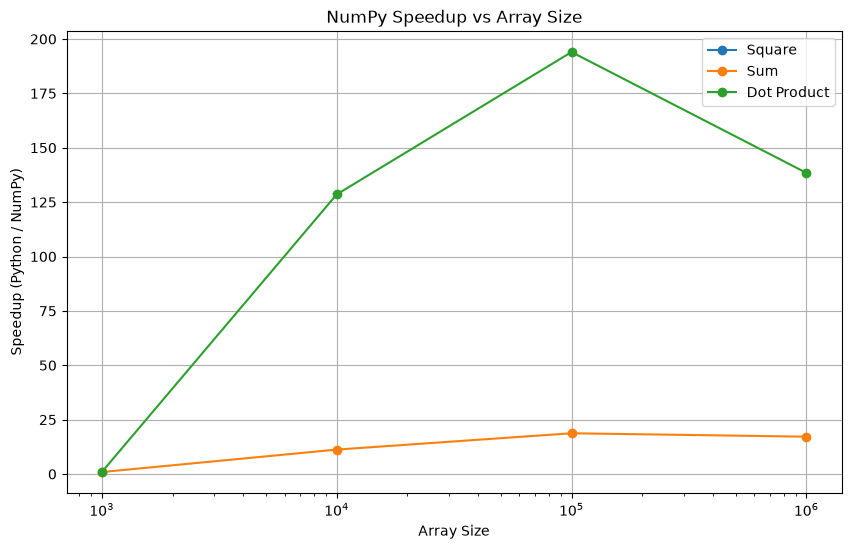

In [14]:
import timeit
import numpy as np
import matplotlib.pyplot as plt

# TASK 03 - Convert loops to NumPy and measure the speedup

array_sizes = [1000, 10000, 100000, 1000000]

results = []


# 1. Squaring every element

for array_size in array_sizes:

    number_list = list(range(array_size)) 
    number_array = np.arange(array_size)

    # Python Loop
    python_square_time = timeit.timeit(
        "[number * number for number in number_list]",
        globals=globals(),\
        number=10
    )/10

    # NumPy vectorised operation
    numpy_square_time = timeit.timeit(
        "number_array ** 2",
        globals=globals(),
        number=10
    )/10

    square_speedup = python_square_time / numpy_square_time

    result.append({
        "size": array_size,
        "operation": "Square",
        "python_time": python_square_time,
        "numpy_time": numpy_square_time,
        "speedup": square_speedup
    })

# 2. Summing all elements

for array_size in array_sizes:

    number_list = list(range(array_size))
    number_array = np.arange(array_size)

    #Python Loop
    python_sum_time = timeit.timeit(
        "sum(number_list)",
        globals=globals(),
        number=10
    ) / 10

    # NumPy vectorised operation
    numpy_sum_time = timeit.timeit(
        "number_array.sum()",
        globals=globals(),
        number=10
    ) / 10

    sum_speedup = python_sum_time / numpy_sum_time

    results.append({
        "size": array_size,
        "operation": "Sum",
        "python_time": python_sum_time,
        "numpy_time": numpy_sum_time,
        "speedup": sum_speedup
    })


# 3. Dot product of two lists

for array_size in array_sizes:

    first_list = list(range(array_size))
    second_list = list(range(array_size))

    first_array = np.arange(array_size)
    second_array = np.arange(array_size)

    # Python loop
    python_dot_time = timeit.timeit(
        "sum(first_value * second_value "
        "for first_value, second_value in zip(first_list, second_list))",
        globals=globals(),
        number=10
    ) / 10

    # NumPy vectorised operation
    numpy_dot_time = timeit.timeit(
        "np.dot(first_array, second_array)",
        globals=globals(),
        number=10
    ) / 10

    dot_speedup = python_dot_time / numpy_dot_time

    results.append({
        "size": array_size,
        "operation": "Dot Product",
        "python_time": python_dot_time,
        "numpy_time": numpy_dot_time,
        "speedup": dot_speedup
    })



# 4. Print results table

print(
    f"{'Operation':<15}"
    f"{'Size':>12}"
    f"{'Python (s)':>15}"
    f"{'NumPy (s)':>15}"
    f"{'Speedup':>12}"
)

print("-" * 69)

for result in results:

    print(
        f"{result['operation']:<15}"
        f"{result['size']:>12,}"
        f"{result['python_time']:>15.6f}"
        f"{result['numpy_time']:>15.6f}"
        f"{result['speedup']:>11.2f}x"
    )

# 5. Plot speedup against array size

plt.figure(figsize=(10, 6))

for operation_name in ["Square", "Sum", "Dot Product"]:

    operation_results = [
        result
        for result in results
        if result["operation"] == operation_name
    ]

    sizes = [
        result["size"]
        for result in operation_results
    ]

    speedups = [
        result["speedup"]
        for result in operation_results
    ]

    plt.plot(
        sizes,
        speedups,
        marker="o",
        label=operation_name
    )


plt.xscale("log")
plt.xlabel("Array Size")
plt.ylabel("Speedup (Python / NumPy)")
plt.title("NumPy Speedup vs Array Size")
plt.legend()
plt.grid(True)
plt.show()











 1. Why must you use `setup=` rather than creating the array inside the timed code?

 Answer: `setup=` keeps array creation outside the timing, so you measure only the operation itself, not the time needed to create the array.

 2. Why does a single timing run give unreliable numbers?

 Answer: A single run can be affected by CPU load, background processes, caching, and other temporary factors. Multiple runs give a more reliable average.

 3. At `n=1000` NumPy's advantage is small. What fixed cost is NumPy paying regardless of size?

 Answer: NumPy has a **fixed overhead** for function calls, array handling, and setup before the actual computation starts. For small arrays, this overhead is significant compared with the computation.


## TASK 04__Broadcasting with mismatched shapes

In [16]:
import numpy as np



# 1. Add (3, 4) array and (4,) array

a = np.ones((3, 4))
b = np.array([1, 2, 3, 4])

result_1 = a + b

print("1. (3,4) + (4,):")
print(result_1)

'''# It works because (4,) is broadcast across all 3 rows.
# NumPy compares the last dimensions: 4 == 4.'''



# 2. Add (3, 4) array and (3,) array

a = np.ones((3, 4))
c = np.array([1, 2, 3])

'''# This will fail:
# result_2 = a + c

# NumPy compares the shapes from right to left:
# (3, 4)
#    (3)
#
# It compares 4 with 3.
# They are different and neither is 1, so broadcasting fails.'''




# 3. Fix the failure using reshape

c = np.array([1, 2, 3])

c_reshaped = c.reshape(3, 1)

result_3 = a + c_reshaped

print("\n3. After reshape:")
print(result_3)

'''# Before reshape: c had shape (3,)
# After reshape: c has shape (3, 1)
#
# Now NumPy compares:
# (3, 4)
# (3, 1)
#
# 1 can broadcast to 4, so addition works.'''




# 4. Add (3, 1) and (1, 4)

x = np.array([
    [1],
    [2],
    [3]
])

y = np.array([
    [10, 20, 30, 40]
])

'''# Expected shape before running:
# (3, 1) + (1, 4) -> (3, 4)'''

result_4 = x + y

print("\n4. (3,1) + (1,4):")
print(result_4)

print("Output shape:", result_4.shape)

'''# Output shape is (3, 4), so the prediction is correct.'''



# 5. 10 x 10 Multiplication Table using Broadcasting

rows = np.arange(1, 11).reshape(-1, 1)   # Shape: (10, 1)
cols = np.arange(1, 11)                  # Shape: (10,)

multiplication_table = rows * cols

print("\n5. 10 x 10 Multiplication Table:")
print(multiplication_table)

'''# (10, 1) * (10,) -> (10, 10)
# No loops are required.'''



# 6. Distance from every point to one reference point

points = np.array([
    [1, 2],
    [3, 4],
    [5, 6],
    [7, 8]
])

reference_point = np.array([0, 0])

differences = points - reference_point

distances = np.sqrt(np.sum(differences ** 2, axis=1))

print("\n6. Distance from every point to reference point:")
print(distances)

'''# reference_point has shape (2,)
# It is broadcast across all points.
#
# Formula:
# distance = sqrt((x1-x2)^2 + (y1-y2)^2)
#
# No loops are required.'''

1. (3,4) + (4,):
[[2. 3. 4. 5.]
 [2. 3. 4. 5.]
 [2. 3. 4. 5.]]

3. After reshape:
[[2. 2. 2. 2.]
 [3. 3. 3. 3.]
 [4. 4. 4. 4.]]

4. (3,1) + (1,4):
[[11 21 31 41]
 [12 22 32 42]
 [13 23 33 43]]
Output shape: (3, 4)

5. 10 x 10 Multiplication Table:
[[  1   2   3   4   5   6   7   8   9  10]
 [  2   4   6   8  10  12  14  16  18  20]
 [  3   6   9  12  15  18  21  24  27  30]
 [  4   8  12  16  20  24  28  32  36  40]
 [  5  10  15  20  25  30  35  40  45  50]
 [  6  12  18  24  30  36  42  48  54  60]
 [  7  14  21  28  35  42  49  56  63  70]
 [  8  16  24  32  40  48  56  64  72  80]
 [  9  18  27  36  45  54  63  72  81  90]
 [ 10  20  30  40  50  60  70  80  90 100]]

6. Distance from every point to reference point:
[ 2.23606798  5.          7.81024968 10.63014581]


'# reference_point has shape (2,)\n# It is broadcast across all points.\n#\n# Formula:\n# distance = sqrt((x1-x2)^2 + (y1-y2)^2)\n#\n# No loops are required.'

**Q16. What is the broadcasting rule? Which direction are shapes compared from?**

**Answer:** Dimensions must be equal or one must be `1`. Shapes are compared **from right to left**.

**Q17. Why does `(3,1) + (1,4)` give `(3,4)`?**

**Answer:** `1` dimensions are expanded to match, so `(3,1)` and `(1,4)` become **(3,4)**.

**Q18. Does broadcasting actually copy the data in memory?**

**Answer:** **No.** Broadcasting usually works without copying data, saving **memory and time**.


## TASK 05__Visualise a 2D array as an image

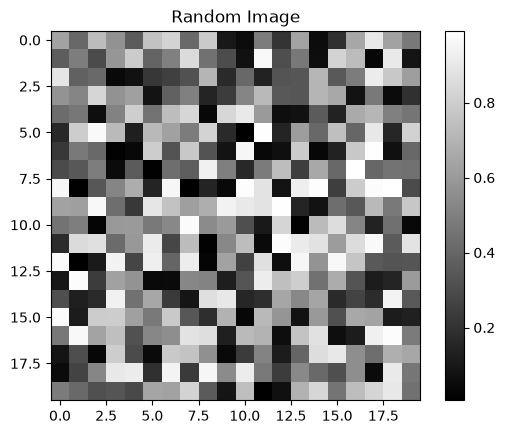

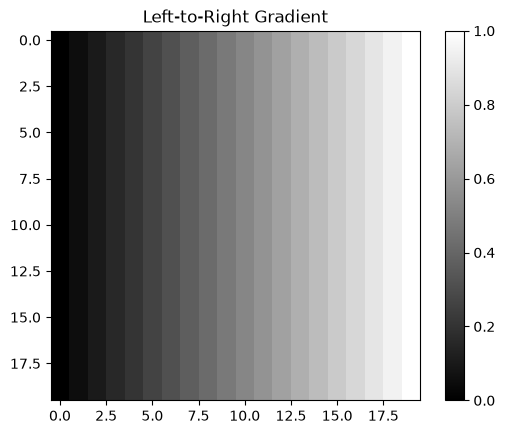

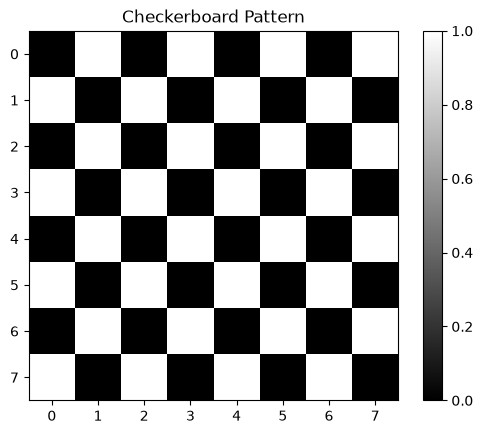

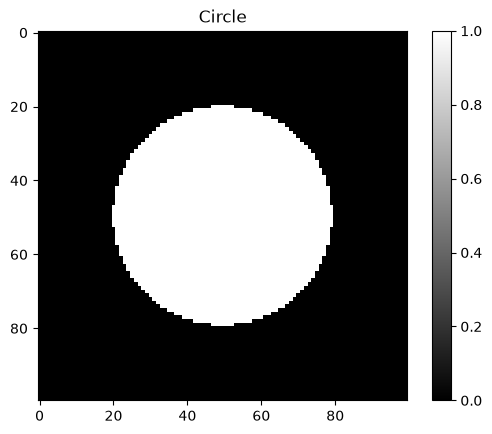

Image shape: (20, 20)
Image dtype: float64


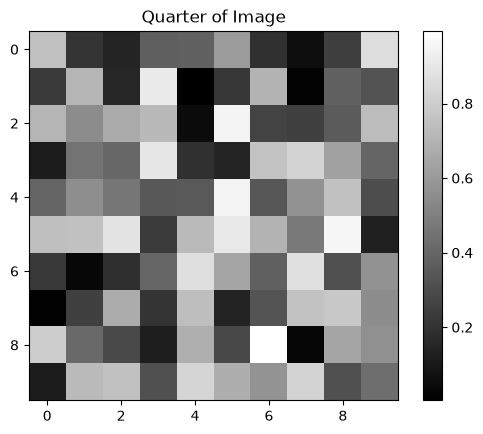

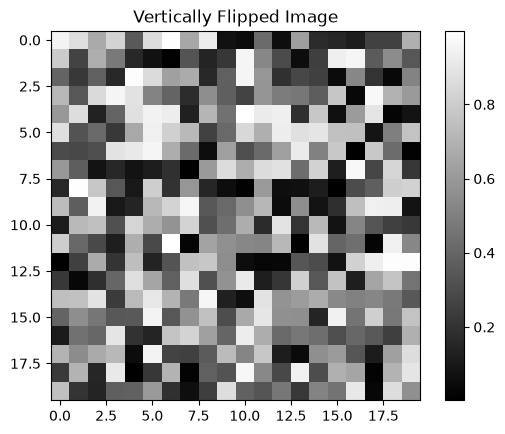

In [17]:
import numpy as np
import matplotlib.pyplot as plt


# 1. Random 2D Array

random_image = np.random.rand(20, 20)

plt.imshow(random_image, cmap="gray")
plt.colorbar()
plt.title("Random Image")
plt.show()



# 2. Create a Gradient

gradient_row = np.linspace(0, 1, 20)

gradient_image = np.tile(gradient_row, (20, 1))

plt.imshow(gradient_image, cmap="gray")
plt.colorbar()
plt.title("Left-to-Right Gradient")
plt.show()


# 3. Create a Checkerboard Pattern

checkerboard = np.zeros((8, 8))

checkerboard[::2, 1::2] = 1
checkerboard[1::2, ::2] = 1

plt.imshow(checkerboard, cmap="gray")
plt.colorbar()
plt.title("Checkerboard Pattern")
plt.show()



# 4. Build a Circle Using Masking

grid_size = 100

x_coordinates = np.linspace(-1, 1, grid_size)
y_coordinates = np.linspace(-1, 1, grid_size)

x_grid, y_grid = np.meshgrid(x_coordinates, y_coordinates)

radius = 0.6

circle_mask = (x_grid ** 2 + y_grid ** 2) <= radius ** 2

circle_image = np.zeros((grid_size, grid_size))
circle_image[circle_mask] = 1

plt.imshow(circle_image, cmap="gray")
plt.colorbar()
plt.title("Circle")
plt.show()



# 5. Create a Small Greyscale Image

grayscale_image = np.random.rand(20, 20)

print("Image shape:", grayscale_image.shape)
print("Image dtype:", grayscale_image.dtype)

quarter_image = grayscale_image[:10, :10]

plt.imshow(quarter_image, cmap="gray")
plt.colorbar()
plt.title("Quarter of Image")
plt.show()



# 6. Flip Image Vertically Using Slicing

flipped_image = grayscale_image[::-1, :]

plt.imshow(flipped_image, cmap="gray")
plt.colorbar()
plt.title("Vertically Flipped Image")
plt.show()

**Q19. For a greyscale image, what do the two numbers in `shape` mean? What would a third number mean for a colour image?**
**Answer:** `(height, width)`; a third number means **colour channels** like RGB `(height, width, 3)`.

**Q20. What does `cmap` change, and why does the default look blue-yellow?**
**Answer:** `cmap` changes the **colour mapping**. The default is usually **viridis**, which goes from blue/purple to yellow.

**Q21. How would you flip an image horizontally instead of vertically?**
**Answer:** Use:

```python
image[:, ::-1]
```

This reverses the **columns**, so the image flips left-to-right.


## Part C — apply it

## TASK 06__A real analysis, no loops

In [18]:
import numpy as np



# 1. Generate Dataset

random_generator = np.random.default_rng(42)

marks = random_generator.integers(
    30, 101, size=(100, 5)
)

print("Dataset shape:", marks.shape)



# 2. Student Average and Exam Average

student_averages = marks.mean(axis=1)   # Average of each student
exam_averages = marks.mean(axis=0)       # Average of each exam

print("Student averages:", student_averages)
print("Exam averages:", exam_averages)



# 3. Students Who Passed

passing_students = student_averages >= 60

number_of_passed_students = np.sum(passing_students)

passing_fraction = number_of_passed_students / len(student_averages)

print("Number of passed students:", number_of_passed_students)
print("Fraction passed:", passing_fraction)




# 4. Top 10 Students

top_student_indices = np.argsort(student_averages)[-10:][::-1]

top_student_scores = student_averages[top_student_indices]

print("Top 10 student indices:", top_student_indices)
print("Top 10 student scores:", top_student_scores)



# 5. Standardise Marks Per Exam

exam_means = marks.mean(axis=0)
exam_standard_deviations = marks.std(axis=0)

standardised_marks = (
    (marks - exam_means) / exam_standard_deviations
)

print("Standardised marks:")
print(standardised_marks)



# 6. Apply Curve: Add 5 Marks and Cap at 100

curved_marks = np.minimum(marks + 5, 100)

marks_that_hit_cap = np.sum(curved_marks == 100)

print("Marks that hit 100:", marks_that_hit_cap)




# 7. Find Students Who Failed Every Exam

failed_every_exam = np.all(marks < 60, axis=1)

students_failed_every_exam = np.where(failed_every_exam)[0]

print(
    "Students who failed every exam:",
    students_failed_every_exam
)

Dataset shape: (100, 5)
Student averages: [63.4 57.  82.4 68.  68.6 70.  61.  67.  58.4 83.  61.8 60.2 78.  60.2
 61.6 61.8 72.2 68.  77.2 57.8 67.2 78.  66.  45.2 73.4 66.8 66.  54.
 70.4 58.  68.8 66.6 70.6 52.8 63.4 68.2 69.  51.2 75.6 56.  71.2 72.6
 71.4 55.  61.  63.8 66.  68.6 59.2 58.8 55.8 53.6 74.8 66.  55.6 56.2
 63.  67.6 70.6 59.6 66.8 49.6 57.6 83.6 71.2 46.6 65.2 75.6 71.8 65.4
 61.8 70.4 71.8 59.2 67.2 61.  60.4 58.8 66.8 53.8 80.  58.2 41.4 66.
 77.6 66.6 60.8 59.2 63.8 68.4 72.2 62.  58.4 69.8 73.4 64.  66.6 64.6
 78.4 61.6]
Exam averages: [66.81 64.08 63.03 64.55 66.17]
Number of passed students: 73
Fraction passed: 0.73
Top 10 student indices: [63  9  2 80 98 21 12 84 18 38]
Top 10 student scores: [83.6 83.  82.4 80.  78.4 78.  78.  77.6 77.2 75.6]
Standardised marks:
[[-1.47781445  0.94688357  0.64710288 -0.18461872 -0.30756294]
 [ 1.11231798 -1.33476359  0.79677972 -1.06870835 -1.50391796]
 [ 0.00911343  1.65989831  0.94645656  1.01150255  0.68939958]
 [ 0.8724909

 1. Why seed the random generator?

 Answer: A seed makes random results **reproducible**. Without it, every run gives different data, so the report's results may change.

 2. What do `np.all()` and `np.any()` do with `axis`?

 Answer:

  `np.all()` → checks if **all values** are True.
  `np.any()` → checks if **at least one value** is True.
  `axis` tells NumPy **which direction to check**.

 3. Why standardise per exam?

 Answer: Each exam may have a different difficulty level. Standardising **per exam** makes student performance comparable relative to that exam's average.
